# 🎯 Guided Learning: Logistic Regression Deep Dive

**Learning Objective:** Understand logistic regression through hands-on exploration, not just code copying!

**Our Journey:**
1. **Understand the Problem** - Why can't we use linear regression for everything?
2. **Real-World Case Study** - Challenger disaster (life or death decisions!)
3. **Build Step by Step** - You'll create each piece with guidance
4. **Complex Dataset** - Titanic survival prediction
5. **Compare & Analyze** - Understanding what the results mean

**Teaching Method:** I'll guide you with questions and hints, YOU write the code! 🚀

## 🤔 Step 1: The Fundamental Question

**Before we start coding, let's understand WHY we need logistic regression!**

**Your Challenge:** Think about these scenarios:
- Will a student pass/fail an exam?
- Will it rain tomorrow (yes/no)?
- Will a patient survive surgery?
- Will a rocket part fail?

**Questions for you:**
1. What do all these problems have in common?
2. If you tried to use linear regression, what would be the problem?
3. What kind of output do we need instead of continuous numbers?

**Your task:** Write your thoughts below before we continue!

In [15]:
# YOUR THOUGHTS: Write your answers as comments

# 1. What do these problems have in common?
# Answer: They are all binary classification problems.

# 2. Problem with linear regression for these cases?
# Answer: Linear regression would be inappropriate.

# 3. What kind of output do we need?
# Answer: We need a probability output between 0 and 1.

print("Ready to explore logistic regression!")

Ready to explore logistic regression!


## 📚 Step 2: Import and Setup

**Your task:** Set up our environment for logistic regression exploration.

**Think about what we need:**
- Data manipulation (pandas, numpy)
- Visualization (matplotlib, seaborn)
- Machine learning (sklearn)

**Your mission:** Import the necessary libraries!

In [16]:
# YOUR TURN: Import the libraries we need!

# For data manipulation:
# import numpy as np
# import pandas as pd

# For visualization:
# import matplotlib as plt
# import seaborn as sns

# For machine learning:
# from sklearn.linear_model import LogisticRegression

# Write your imports here:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression


print("Libraries imported successfully!")

Libraries imported successfully!


## 🚀 Step 3: The Challenger Disaster Case Study

**Real History:** January 28, 1986 - Space Shuttle Challenger exploded, killing 7 astronauts.
**Cause:** O-ring failure due to cold temperature (below 30°F)
**Tragedy:** Engineers had data showing the risk but couldn't present it convincingly.

**The Data Question:** Can we predict O-ring failure based on temperature?

**Your Learning Mission:**
1. Understand what the data represents
2. Visualize the relationship
3. Build a model that could have saved lives

**First, let's load the data:**

In [17]:
# Load the Challenger O-ring failure data
# Note: This data comes from actual NASA records

challenger_data = np.array([
    [66, 0], [70, 1], [69, 0], [68, 0], [67, 0], [72, 0],
    [73, 0], [70, 0], [57, 1], [63, 1], [70, 1], [78, 0],
    [67, 0], [53, 1], [67, 0], [75, 0], [70, 0], [81, 0],
    [76, 0], [79, 0], [75, 1], [76, 0], [58, 1]
])

print("Challenger O-ring data loaded")
print("Shape:", challenger_data.shape)
print("First 5 rows:")
print(challenger_data[:5])

# YOUR TASK: What do you think each column represents?
# Column 0: Temperature in Fahrenheit
# Column 1: O-ring failure (1) or no failure (0)

Challenger O-ring data loaded
Shape: (23, 2)
First 5 rows:
[[66  0]
 [70  1]
 [69  0]
 [68  0]
 [67  0]]


## 🔍 Step 4: Explore the Challenger Data

**Your task:** Create a pandas DataFrame and visualize the relationship.

**Questions to guide you:**
1. What should we name the columns?
2. What type of plot would show the relationship best?
3. What pattern do you expect to see?

**Your mission:** Convert to DataFrame and create a scatter plot!

Data summary:
   Temperature (F)  O-ring Failure
0               66               0
1               70               1
2               69               0
3               68               0
4               67               0
       Temperature (F)  O-ring Failure
count        23.000000       23.000000
mean         69.565217        0.304348
std           7.057080        0.470472
min          53.000000        0.000000
25%          67.000000        0.000000
50%          70.000000        0.000000
75%          75.000000        1.000000
max          81.000000        1.000000


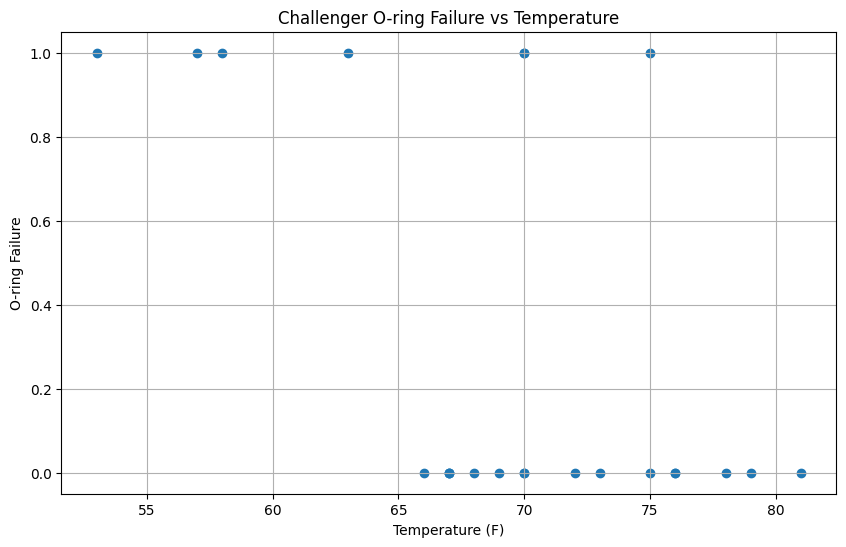

In [18]:
# YOUR TURN: Create DataFrame and visualize

# Step 1: Create DataFrame with meaningful column names
challenger_df = pd.DataFrame (challenger_data, columns = ['Temperature (F)', 'O-ring Failure'])

# Step 2: Display basic info
print("Data summary:")
print(challenger_df.head())  # Print the first few rows
print(challenger_df.describe())  # Print basic statistics

# Step 3: Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(challenger_df['Temperature (F)'], challenger_df['O-ring Failure'])
plt.xlabel('Temperature (F)')
plt.ylabel('O-ring Failure')
plt.title('Challenger O-ring Failure vs Temperature')
plt.grid(True)

plt.show()

# YOUR ANALYSIS: What pattern do you see?
# Write your observations as comments:
# Pattern observed: 

## 🧠 Step 5: Understanding the Problem

**Critical Thinking Questions:**

Looking at your scatter plot:
1. **What happens to failure rate as temperature decreases?**
2. **Why can't we use linear regression here?**
3. **What would linear regression predict for temperature = 30°F?**
4. **What's wrong with predicting failure = 1.5 or failure = -0.3?**

**Your task:** Answer these questions and understand why we need logistic regression!

In [19]:
# YOUR ANALYSIS: Answer the critical questions

# 1. What happens to failure rate as temperature decreases?
# Answer: INCREASES! As temperature gets colder, O-rings are more likely to fail.

# 2. Why can't we use linear regression here?
# Answer: Linear regression assumes a linear relationship between input and output, which is not the case here.

# 3. What would linear regression predict for temperature = 30°F?
# Answer: Could predict impossible values like -0.5 or 1.8 (outside 0-1 range).

# 4. What's wrong with predicting failure = 1.5 or failure = -0.3?
# Answer: These predictions are not valid as failure rates must be between 0 and 1.

# 5. What range of values do we need for predictions?
# Answer: We need a range of values between 0 and 1 for predictions.

print("Critical thinking complete! Ready for logistic regression.")

Critical thinking complete! Ready for logistic regression.


## 🔧 Step 6: Build Your First Logistic Regression Model

**Your task:** Create and train a logistic regression model step by step.

**Process to follow:**
1. Prepare the data (X and y)
2. Create the model
3. Fit the model
4. Evaluate the model

**Your mission:** Fill in each step with guidance!

In [24]:
# YOUR TURN: Build the logistic regression model!

# Step 1: Prepare the data
# What should X be? (features)
X = challenger_df[['Temperature (F)']].values  # Extract temperature data in the right shape

# What should y be? (target)
y = challenger_df['O-ring Failure'].values  # Extract failure data

print("Data shapes:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Step 2: Create the model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()  # ??? Create LogisticRegression instance

# Step 3: Train the model
model.fit(X.reshape(-1, 1), y)  # ??? Fit the model with X and y

# Step 4: Evaluate basic performance
accuracy = model.score(X.reshape(-1, 1), y)  # ??? Calculate model score
print(f"Model accuracy: {accuracy:.3f}")

print("Model trained successfully!")

Data shapes:
X shape: (23, 1)
y shape: (23,)
Model accuracy: 0.870
Model trained successfully!


## 📊 Step 7: Understand Model Predictions

**Key Insight:** Logistic regression gives us TWO types of predictions:
1. **Binary predictions** (0 or 1): Hard classifications
2. **Probabilities** (0.0 to 1.0): How confident is the model?

**Your task:** Explore both types of predictions and understand the difference!

**Critical Question:** For the Challenger launch at 26-29°F, what would the model predict?

In [27]:
# YOUR TURN: Explore model predictions!

# Step 1: Make binary predictions
binary_predictions = model.predict(X.reshape(-1, 1))

# Step 2: Get probability predictions  
probability_predictions = model.predict_proba(X.reshape(-1, 1))

print("First 5 predictions:")
print("Temperature | Actual | Predicted | Probability")
for i in range(5):
    temp = X[i, 0]
    actual = y[i]
    pred = binary_predictions[i]
    prob = probability_predictions[i, 1]  # Probability of failure
    print(f"{temp:8.0f}°F | {actual:6d} | {pred:9d} | {prob:11.3f}")

# Step 3: THE CRITICAL QUESTION - Challenger launch temperature
launch_temp = np.array([[28]])  # 28°F (middle of predicted range)

predicted_failure = model.predict(launch_temp)
failure_probability = model.predict_proba(launch_temp)

print(f"\n🚨 CHALLENGER PREDICTION at 28°F:")
print(f"Predicted failure: {predicted_failure[0]}")
print(f"Failure probability: {failure_probability[0][1]:.3f}")

# YOUR ANALYSIS: What does this tell us?
# If engineers had this model, what would they conclude?
# Write your thoughts:

First 5 predictions:
Temperature | Actual | Predicted | Probability
      66°F |      0 |         0 |       0.429
      70°F |      1 |         0 |       0.231
      69°F |      0 |         0 |       0.274
      68°F |      0 |         0 |       0.322
      67°F |      0 |         0 |       0.374

🚨 CHALLENGER PREDICTION at 28°F:
Predicted failure: 1
Failure probability: 1.000


## 📈 Step 8: Visualize the Logistic Curve

**Your task:** Create a plot that shows the S-shaped logistic curve alongside the actual data.

**Key Learning:** Unlike linear regression's straight line, logistic regression creates an S-curve that:
- Stays between 0 and 1
- Shows probability of the outcome
- Has a smooth transition

**Your mission:** Plot the actual data points and the fitted probability curve!

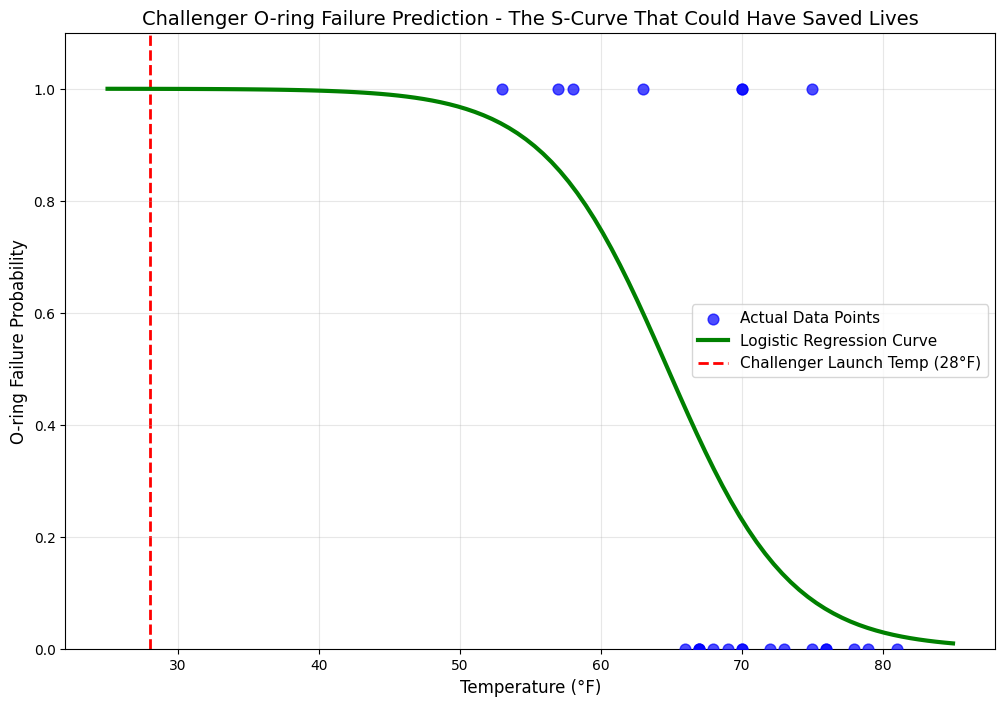

In [ ]:
# YOUR TURN: Create the logistic curve visualization!

# Step 1: Create a range of temperatures for smooth curve
temp_range = np.linspace(25, 85, 100).reshape(-1, 1)

# Step 2: Get probability predictions for the full range
curve_probabilities = model.predict_proba(temp_range)

# Step 3: Create ONE combined plot
plt.figure(figsize=(12, 8))

# Plot actual data points (from original dataset)
plt.scatter(X.flatten(), y, color='blue', s=60, alpha=0.7, label='Actual Data Points', zorder=3)

# Plot the logistic S-curve
plt.plot(temp_range.flatten(), curve_probabilities[:, 1], color='green', linewidth=3, label='Logistic Regression Curve', zorder=2)

# Add the critical temperature line
plt.axvline(x=28, color='red', linestyle='--', linewidth=2, label='Challenger Launch Temp (28°F)', zorder=1)

# Add labels, title, legend, and formatting
plt.xlabel('Temperature (°F)', fontsize=12)
plt.ylabel('O-ring Failure Probability', fontsize=12)
plt.title('Challenger O-ring Failure Prediction - The S-Curve That Could Have Saved Lives', fontsize=14)
plt.legend(fontsize=11)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)

plt.show()

# YOUR ANALYSIS: Describe what you see in the curve
# How does failure probability change with temperature?
# What's the probability at 28°F?

# Write your observations:
# 1. Shape of the curve: 
# 2. What happens as temperature decreases below 60°F?
# 3. At 28°F (Challenger launch), what's the failure probability?
# 4. Could this model have prevented the disaster?